# Customer Churn Prediction
### For Telecommunication Service Provider

## Objective
**To apply a feedforward neural network to predict customer churn and to identify the key behavioural and service-related factors that influence customer retention.**

In [1]:
# Importing basic necesaary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# installing tenserflow for neural networks
!pip install tensorflow

In [3]:
# importing tenserflow libraries for neural network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Data Understanding and Preparation

### Loading & Reading Dataset

In [4]:
# Loading dataset from the file provided
df = pd.read_csv("D:/BITS DS & AI/Trimester 2/Artificial Neural Networks/telco_churn.csv")

In [5]:
# reading dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [7]:
# information about dataset records, index, variables, data types and storage memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Dictionary:**    

- customerID - Unique identifier for each customer Categorical (ID) Not useful for modeling    
- gender - Customer gender Categorical Male / Female     
- SeniorCitizen - Indicates if customer is a senior citizen Binary (0/1) 1 = Senior Citizen     
- Partner- Whether customer has a partner Categorical Yes / No      
- Dependents- Whether customer has dependents Categorical Yes / No     
- tenure- Number of months customer stayed Numerical Higher implies loyalty     
- PhoneService -Whether customer has phone service Categorical Yes / No     
- MultipleLines- Multiple phone lines Categorical Yes / No / No phone service     
- InternetService- Type of internet service Categorical DSL / Fiber / None     
- OnlineSecurity- Online security service Categorical Yes / No / No internet service     
- OnlineBackup- Online backup service Categorical Yes / No / No internet service     
- DeviceProtection- Device protection service Categorical Yes / No / No internet service     
- TechSupport- Technical support service Categorical Yes / No / No internet service     
- StreamingTV- Streaming TV service Categorical Yes / No / No internet service     
- StreamingMovies- Streaming movies service Categorical Yes / No / No internet service     
- Contract- Contract duration Categorical Month-to-month / One year / Two year     
- PaperlessBilling-  Paperless billing usage Categorical Yes / No PaymentMethod     
- Payment method - Categorical Electronic / Mailed / Bank / Credit     
- MonthlyCharges - Monthly charges Numerical Continuous     
- TotalCharges -  Total charges over tenure Numerical May contain missing values     
- Churn - Customer churn indicator Target (Binary) Yes = Churned    

In [8]:
# Total charges variables is stored as categorical instead of numeric
# Changing its data type to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [9]:
# finding if there are any null enteries
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**No null enteries found**

In [10]:
# finding if there are any duplicate records
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**no duplicate records found**

In [11]:
# distinct values in each variable
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

##### **Explicitly defining categorical columns and numeric columns for effecient pre-processing, EDA and cleaner pipleine**

In [12]:
# dropping customerID bcause its only an identifier, has no significance for the analysis
df1 = df.drop(['customerID'], axis=1)

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['number']).columns

print(cat_cols)
print(num_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [14]:
df[cat_cols].describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [15]:
df[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
# Mapping Target Variable to binary format
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

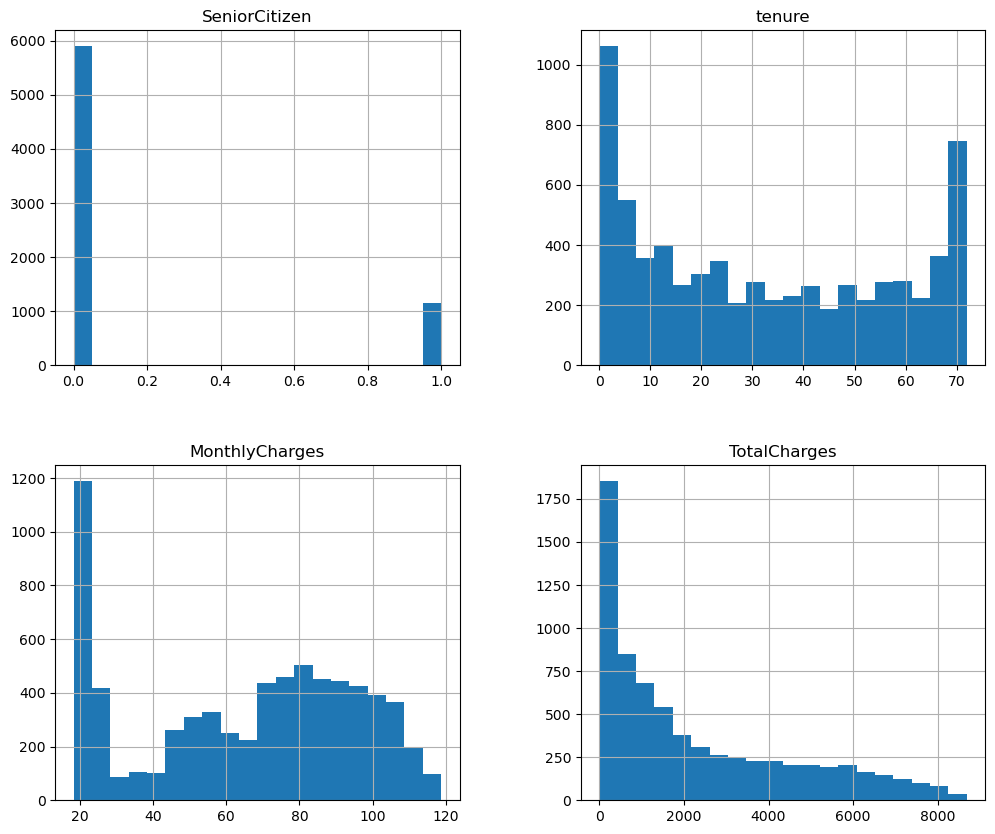

In [17]:
# Distribution of numbered columns in the dataset
df[num_cols].hist(figsize=(12,10), bins=20)
plt.show()

In [18]:
# Log transform to reduce right skewness
df['TotalCharges'] = np.log1p(df['TotalCharges'])

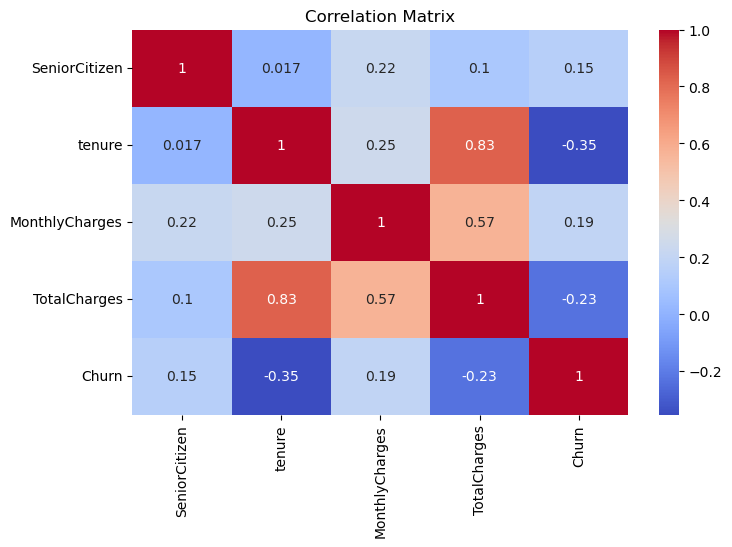

In [19]:
# Correlation Analysis
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix revealed a strong positive correlation (0.83) between tenure and total charges, indicating multicollinearity. Since total charges is a cumulative measure derived from tenure and monthly charges, it does not provide independent predictive value. Therefore, the original TotalCharges feature was removed.

In [20]:
df1 = df.drop('TotalCharges', axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

Percentage of Customer Churn Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


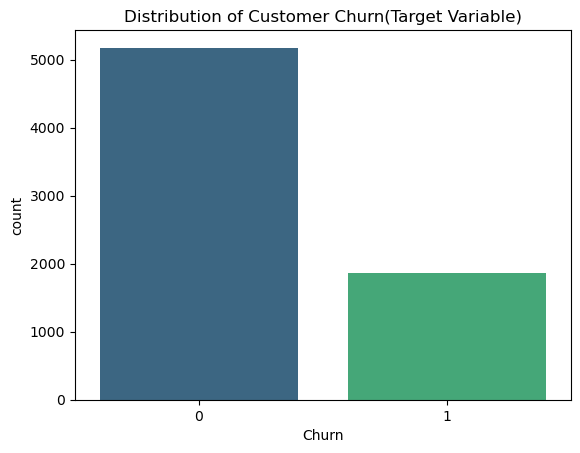

In [21]:
# Visualizing the target variable
counts = df['Churn'].value_counts()
percent = df['Churn'].value_counts(normalize=True) * 100
print("Percentage of Customer Churn",percent)
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn(Target Variable)')
plt.show()

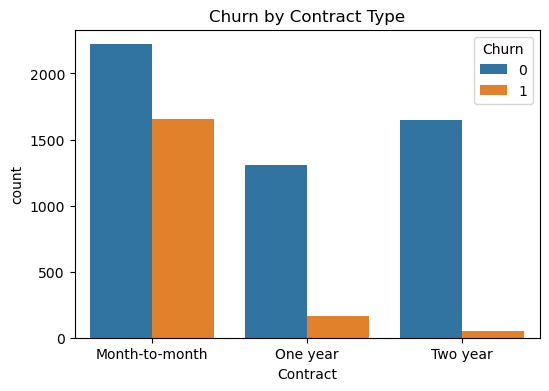

In [22]:
# Visualizing target variable 
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

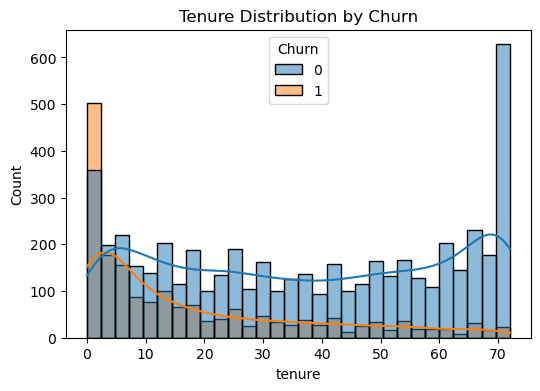

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

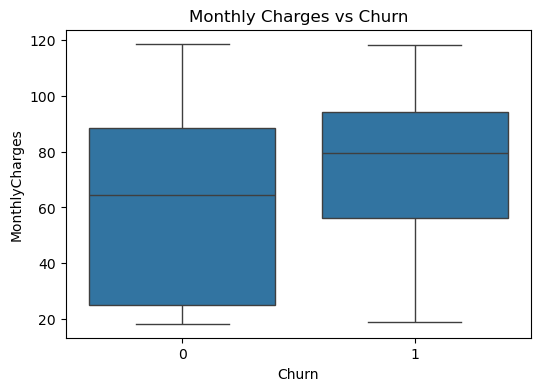

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

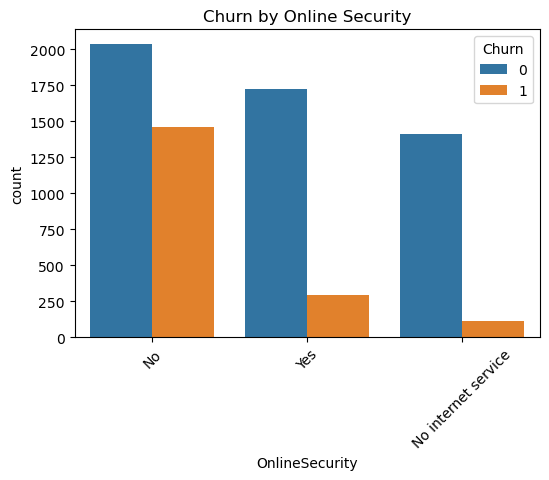

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Online Security")
plt.show()

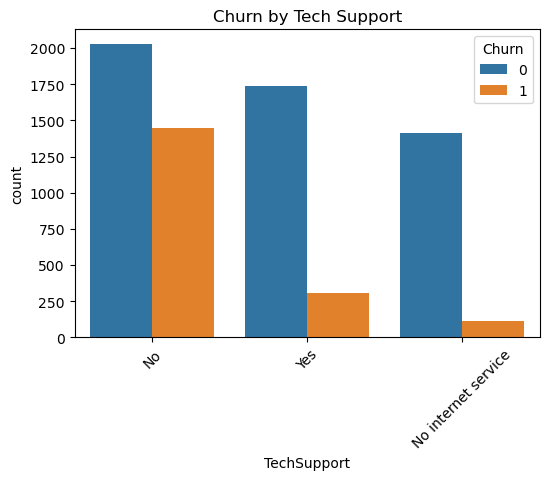

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Tech Support")
plt.show()

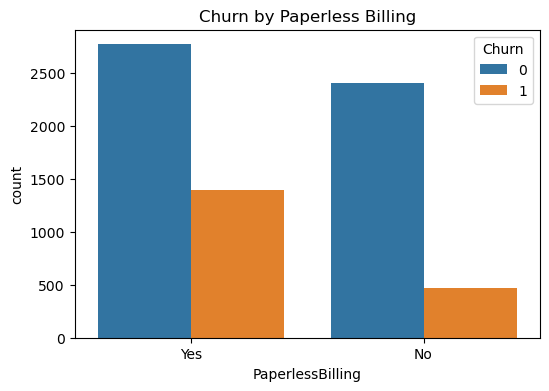

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Churn by Paperless Billing")
plt.show()

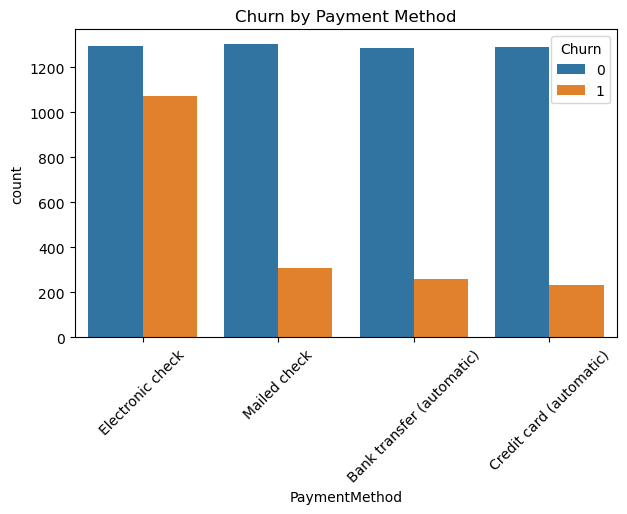

In [28]:
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

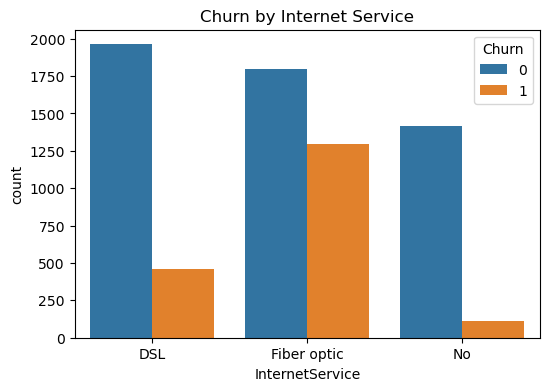

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

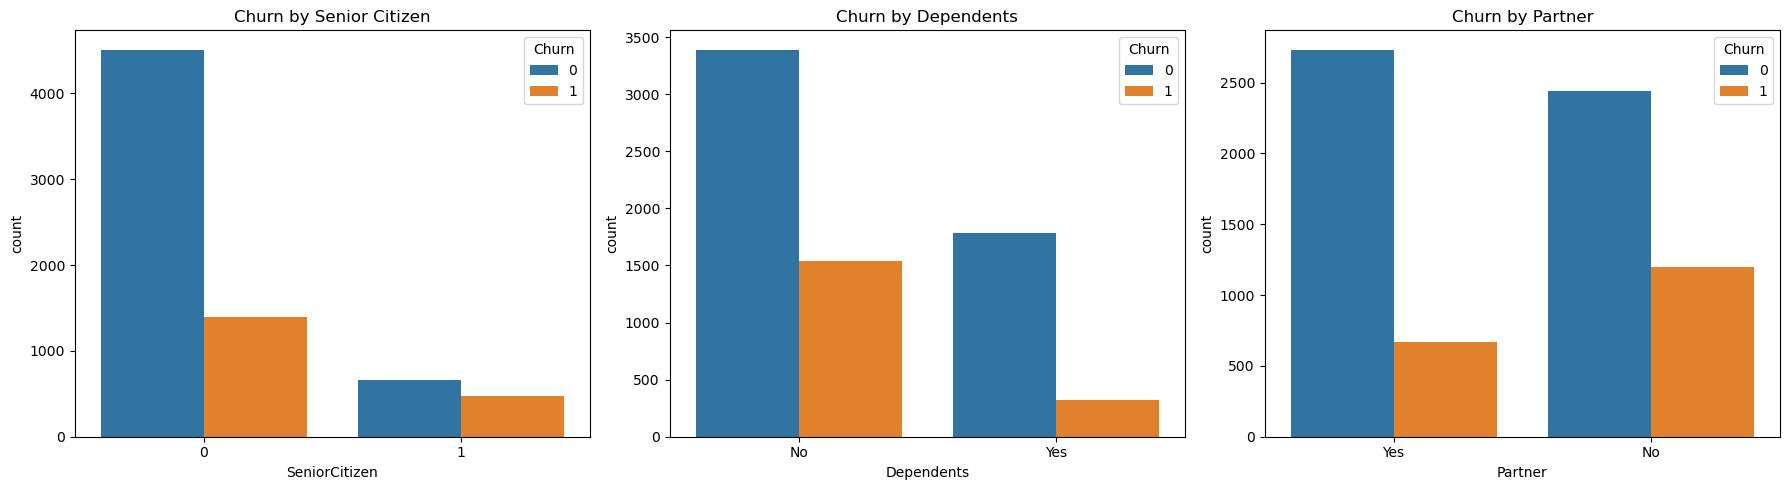

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[0])
axes[0].set_title("Churn by Senior Citizen")

# Dependents
sns.countplot(x='Dependents', hue='Churn', data=df, ax=axes[1])
axes[1].set_title("Churn by Dependents")

# Partner
sns.countplot(x='Partner', hue='Churn', data=df, ax=axes[2])
axes[2].set_title("Churn by Partner")

plt.tight_layout()
plt.show()

### One-Hot Encoding 

In [31]:
df1 = pd.get_dummies(df, drop_first=True)

In [32]:
df1.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

### Splitting into Train/Test Dataset

In [33]:
X = df1.drop('Churn', axis=1)
y = df1['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [34]:
# Scaling numerical variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
# Deploying random forest for findind feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

                                  Feature  Importance
1                                  tenure    0.244313
2                          MonthlyCharges    0.228766
9             InternetService_Fiber optic    0.046118
27         PaymentMethod_Electronic check    0.038810
24                      Contract_Two year    0.037882
3                             gender_Male    0.033819
18                        TechSupport_Yes    0.029063
23                      Contract_One year    0.028737
25                   PaperlessBilling_Yes    0.028292
4                             Partner_Yes    0.027656
12                     OnlineSecurity_Yes    0.027316
14                       OnlineBackup_Yes    0.025626
0                           SeniorCitizen    0.023304
8                       MultipleLines_Yes    0.023255
5                          Dependents_Yes    0.022355
16                   DeviceProtection_Yes    0.022131
22                    StreamingMovies_Yes    0.020827
20                        St

## Neural Network Modelling

In [36]:
model = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
   metrics=['accuracy', 'Precision', 'Recall']
)

model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Precision: 0.4074 - Recall: 0.2908 - accuracy: 0.7022 - loss: 0.5481 
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6444 - Recall: 0.4622 - accuracy: 0.7914 - loss: 0.4457 
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6361 - Recall: 0.5250 - accuracy: 0.7961 - loss: 0.4296 
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6450 - Recall: 0.5344 - accuracy: 0.8001 - loss: 0.4242 
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6493 - Recall: 0.5297 - accuracy: 0.8010 - loss: 0.4186 
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6529 - Recall: 0.5331 - accuracy: 0.8026 - loss: 0.4159 
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6547 - Recall: 0.5412 - accuracy: 0.8042 - loss: 0.4135 
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.6586 - Recall: 0.5479 - accuracy: 0.8064 - loss: 0.4117 
Epoch 9/

The input features were selected based on correlation analysis and domain relevance. Features such as tenure and MonthlyCharges were retained as they showed meaningful relationships with the target variable (churn) and represent customer behavior and pricing sensitivity. The feature TotalCharges was removed due to high multicollinearity with tenure (correlation ≈ 0.83).    
This selection ensures that the model uses informative, non-redundant, and scaled features, which improves learning efficiency and generalization in neural networks.

Loss Function (Binary Crossentropy)
The loss function used is binary crossentropy, which is appropriate for binary classification problems such as churn prediction (Yes/No). It measures the difference between the predicted probabilities and actual class labels. Since the output layer uses a sigmoid activation function, binary crossentropy is the most suitable choice as it penalizes incorrect predictions more effectively and helps the model converge faster.

Evaluation Metrics

The primary evaluation metric used is accuracy, which measures the proportion of correctly classified instances. However, since churn datasets are often imbalanced, accuracy alone may not fully capture model performance. Therefore, additional metrics such as precision, recall, and F1-score are recommended:

Precision: Measures how many predicted churn cases are actually correct
Recall: Measures how many actual churn cases are correctly identified
F1-score: Provides a balance between precision and recall

These metrics ensure a more comprehensive evaluation, especially in identifying customers likely to churn.

## Evaluation and Interpretation

In [41]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1022
           1       0.56      0.71      0.63       387

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.77      1409

[[804 218]
 [111 276]]


The model performs well overall with 80% accuracy, but struggles to identify churn customers, as indicated by the low recall (51%) for class 1. This suggests that the model is biased towards the majority class (non-churn), which is common in imbalanced datasets.

In [42]:
model.fit(X_train, y_train, 
          epochs=20, 
          batch_size=32,
          class_weight={0:1, 1:2})

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5871 - Recall: 0.7503 - accuracy: 0.7955 - loss: 0.5623 
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5932 - Recall: 0.7368 - accuracy: 0.7978 - loss: 0.5618 
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5951 - Recall: 0.7449 - accuracy: 0.7996 - loss: 0.5612 
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5940 - Recall: 0.7571 - accuracy: 0.8000 - loss: 0.5582 
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5947 - Recall: 0.7395 - accuracy: 0.7989 - loss: 0.5596   
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5885 - Recall: 0.7470 - accuracy: 0.7961 - loss: 0.5592 
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5979 - Recall: 0.7476 - accuracy: 0.8014 - loss: 0.5577 
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5889 - Recall: 0.7618 - accuracy: 0.7975 - loss: 0.5589 
Epoch 

In [46]:
y_prob = model.predict(X_test) 
y_pred = (y_prob > 0.3).astype(int)

print(classification_report(y_test, y_pred_1))
print(confusion_matrix(y_test, y_pred_1))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1022
           1       0.59      0.66      0.62       387

    accuracy                           0.78      1409
   macro avg       0.73      0.74      0.74      1409
weighted avg       0.79      0.78      0.79      1409

[[848 174]
 [133 254]]


**What the Model Captures Well**

The model performs very well in identifying non-churn customers (Class 0):

High recall (0.91) indicates that most non-churn cases are correctly classified.
Strong F1-score (0.87) shows a good balance between precision and recall for this class.

This suggests that the model successfully learns patterns associated with customer retention, such as:

Longer tenure   
Stable billing behavior   
Contract-based customers    

Additionally:

Overall accuracy (80%) and weighted F1-score (0.79) indicate good general performance.    
The model effectively captures dominant patterns in the dataset, especially from the majority class.

**Where the Model Fails**

The model struggles with identifying churn customers (Class 1):

Low recall (0.51) → nearly half of actual churn cases are missed    
F1-score (0.58) is significantly lower compared to non-churn class    

This means:

The model has a high number of false negatives (191 cases)    
It fails to detect many customers who are actually at risk of leaving       
Key Limitation  

The model is biased toward the majority class (non-churn) due to class imbalance, leading to poor detection of churn cases.